In [1]:
import pandas as pd

In [3]:
seller_analysis = pd.read_csv("seller_analysis_clean.csv")
seller_order_level = pd.read_csv("seller_order_level_clean.csv")
seller_summary_delivered = pd.read_csv("seller_summary_delivered.csv")
delivered_orders = pd.read_csv("delivered_orders_clean.csv")

In [5]:
#Because CSV files do not preserve datetime types automatically, we convert the important dates again
seller_analysis["won_date"] = pd.to_datetime(seller_analysis["won_date"])

seller_analysis["first_sale_date"] = pd.to_datetime(seller_analysis["first_sale_date"])

seller_order_level["order_purchase_timestamp"] = pd.to_datetime(seller_order_level["order_purchase_timestamp"])

In [7]:
print("Seller analysis:", seller_analysis.shape)
print("Seller order level:", seller_order_level.shape)
print("Delivered seller summary:", seller_summary_delivered.shape)
print("Delivered orders:", delivered_orders.shape)

Seller analysis: (842, 27)
Seller order level: (100010, 9)
Delivered seller summary: (2970, 4)
Delivered orders: (96470, 9)


# Olist Seller Evaluation & Channel Analysis
## Assigned Analysis Questions
Which employees are hiring the best vs. worst sellers?

Provide specific, data-driven recommendations.

Explore population density and demographics in states with no sellers.

Compare average revenue per order between manufacturers and resellers.

Assess whether seller location affects delivery time.

Which lead channel (e.g., Organic Search, Paid Search, Social) brings sellers with the highest retention and order volume?

What percentage of signed sellers never list a product or make their first sale within 30/60 days of onboarding?

## 1. Which employees are hiring the best vs. worst sellers?

In [12]:
#active seller” flag
seller_analysis["active_seller"] = seller_analysis["total_orders"].notna()
seller_analysis["active_seller"].value_counts()

active_seller
False    462
True     380
Name: count, dtype: int64

In [14]:
#SR performance table
sr_summary = seller_analysis.groupby("sr_id").agg(
    sellers_hired=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    average_orders=("total_orders", "mean"),
    average_revenue=("total_revenue", "mean"),
    average_review=("average_review_score", "mean")
).reset_index()

In [16]:
#activation rate
sr_summary["active_rate"] = (sr_summary["active_sellers"] /sr_summary["sellers_hired"]) * 100

In [18]:
sr_summary

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
0,060c0a26f19f4d66b42e0d8796688490,32,14,25.928571,3899.695714,4.472581,43.750000
1,068066e24f0c643eb1d089c7dd20cd73,27,6,17.166667,1150.760000,4.302108,22.222222
2,0a0fb2b07d841f84fb6714e35c723075,1,0,NaN,NaN,NaN,0.000000
3,2695de1affa7750089c0455f8ce27021,59,21,9.142857,1908.062857,4.205884,35.593220
4,34d40cdaf94010a1d05b0d6212f9e909,10,2,15.000000,2416.215000,4.300000,20.000000
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,10.827586,1108.305862,4.212246,46.031746
6,4b339f9567d060bcea4f5136b9f5949e,9,1,2.000000,102.050000,5.000000,11.111111
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,75,10.173333,1314.829867,4.267174,56.390977
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.181818,1440.772727,4.696966,45.833333
9,6565aa9ce3178a5caf6171827af3a9ba,74,36,9.111111,1328.230833,4.254038,48.648649


In [20]:
#filter out very small employee samples
sr_summary_fair = sr_summary[sr_summary["sellers_hired"] >= 10].copy()

print("SRs included:", len(sr_summary_fair))

SRs included: 16


In [22]:
#strongest activation rates
sr_summary_fair.sort_values("active_rate",ascending=False)

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,75,10.173333,1314.829867,4.267174,56.390977
21,fbf4aef3f6915dc0c3c97d6812522f6a,59,30,6.466667,1038.645667,4.283479,50.847458
11,85fc447d336637ba1df43e793199fbc8,64,32,5.750000,1296.541250,4.074548,50.000000
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,17.916667,1558.800833,4.074101,50.000000
16,a8387c01a09e99ce014107505b92388c,26,13,5.692308,464.442308,4.461538,50.000000
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,11.000000,1120.315610,4.411704,50.000000
9,6565aa9ce3178a5caf6171827af3a9ba,74,36,9.111111,1328.230833,4.254038,48.648649
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,10.827586,1108.305862,4.212246,46.031746
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.181818,1440.772727,4.696966,45.833333
13,9ae085775a198122c5586fa830ff7f2b,51,23,33.956522,5934.306087,4.366703,45.098039


In [24]:
#strongest average order volume
sr_summary_fair.sort_values("average_orders",ascending=False)

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
13,9ae085775a198122c5586fa830ff7f2b,51,23,33.956522,5934.306087,4.366703,45.098039
0,060c0a26f19f4d66b42e0d8796688490,32,14,25.928571,3899.695714,4.472581,43.750000
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,17.916667,1558.800833,4.074101,50.000000
1,068066e24f0c643eb1d089c7dd20cd73,27,6,17.166667,1150.760000,4.302108,22.222222
18,c638112b43f1d1b86dcabb0da720c901,36,15,16.666667,4617.330000,4.383532,41.666667
4,34d40cdaf94010a1d05b0d6212f9e909,10,2,15.000000,2416.215000,4.300000,20.000000
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.181818,1440.772727,4.696966,45.833333
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,11.000000,1120.315610,4.411704,50.000000
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,10.827586,1108.305862,4.212246,46.031746
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,75,10.173333,1314.829867,4.267174,56.390977


In [28]:
#strongest average revenue
sr_summary_fair.sort_values("average_revenue",ascending=False)

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
13,9ae085775a198122c5586fa830ff7f2b,51,23,33.956522,5934.306087,4.366703,45.098039
18,c638112b43f1d1b86dcabb0da720c901,36,15,16.666667,4617.330000,4.383532,41.666667
0,060c0a26f19f4d66b42e0d8796688490,32,14,25.928571,3899.695714,4.472581,43.750000
4,34d40cdaf94010a1d05b0d6212f9e909,10,2,15.000000,2416.215000,4.300000,20.000000
3,2695de1affa7750089c0455f8ce27021,59,21,9.142857,1908.062857,4.205884,35.593220
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,17.916667,1558.800833,4.074101,50.000000
20,de63de0d10a6012430098db33c679b0b,53,18,8.333333,1489.193333,4.354577,33.962264
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.181818,1440.772727,4.696966,45.833333
9,6565aa9ce3178a5caf6171827af3a9ba,74,36,9.111111,1328.230833,4.254038,48.648649
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,75,10.173333,1314.829867,4.267174,56.390977


In [32]:
#separate analysis copy
sr_analysis_data = seller_analysis.copy()

In [34]:
#treat sellers with no recorded transactions as zero for this specific employee-performance calculation
sr_analysis_data["total_orders_for_employee"] = (sr_analysis_data["total_orders"].fillna(0))

sr_analysis_data["total_revenue_for_employee"] = (sr_analysis_data["total_revenue"].fillna(0))

In [36]:
#overall SR table
sr_overall = sr_analysis_data.groupby("sr_id").agg(
    sellers_hired=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    total_orders=("total_orders_for_employee", "sum"),
    total_revenue=("total_revenue_for_employee", "sum"),
    average_review=("average_review_score", "mean")
).reset_index()

In [38]:
sr_overall["active_rate"] = (sr_overall["active_sellers"] /sr_overall["sellers_hired"]) * 100

In [40]:
#productivity per seller hired
sr_overall["orders_per_hired_seller"] = (sr_overall["total_orders"] /sr_overall["sellers_hired"])

sr_overall["revenue_per_hired_seller"] = (sr_overall["total_revenue"] /sr_overall["sellers_hired"])

In [42]:
sr_overall_fair = sr_overall[sr_overall["sellers_hired"] >= 10].copy()

In [44]:
sr_overall_fair.sort_values("revenue_per_hired_seller",ascending=False)

,sr_id,sellers_hired,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_hired_seller,revenue_per_hired_seller
13,9ae085775a198122c5586fa830ff7f2b,51,23,781.0,136489.04,4.366703,45.098039,15.313725,2676.255686
18,c638112b43f1d1b86dcabb0da720c901,36,15,250.0,69259.95,4.383532,41.666667,6.944444,1923.887500
0,060c0a26f19f4d66b42e0d8796688490,32,14,363.0,54595.74,4.472581,43.750000,11.343750,1706.116875
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,215.0,18705.61,4.074101,50.000000,8.958333,779.400417
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,75,763.0,98612.24,4.267174,56.390977,5.736842,741.445414
3,2695de1affa7750089c0455f8ce27021,59,21,192.0,40069.32,4.205884,35.593220,3.254237,679.141017
8,56bf83c4bb35763a51c2baab501b4c67,24,11,123.0,15848.50,4.696966,45.833333,5.125000,660.354167
11,85fc447d336637ba1df43e793199fbc8,64,32,184.0,41489.32,4.074548,50.000000,2.875000,648.270625
9,6565aa9ce3178a5caf6171827af3a9ba,74,36,328.0,47816.31,4.254038,48.648649,4.432432,646.166351
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,451.0,45932.94,4.411704,50.000000,5.500000,560.157805


In [46]:
sr_overall_fair.sort_values("orders_per_hired_seller",ascending=False)

,sr_id,sellers_hired,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_hired_seller,revenue_per_hired_seller
13,9ae085775a198122c5586fa830ff7f2b,51,23,781.0,136489.04,4.366703,45.098039,15.313725,2676.255686
0,060c0a26f19f4d66b42e0d8796688490,32,14,363.0,54595.74,4.472581,43.750000,11.343750,1706.116875
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,215.0,18705.61,4.074101,50.000000,8.958333,779.400417
18,c638112b43f1d1b86dcabb0da720c901,36,15,250.0,69259.95,4.383532,41.666667,6.944444,1923.887500
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,75,763.0,98612.24,4.267174,56.390977,5.736842,741.445414
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,451.0,45932.94,4.411704,50.000000,5.500000,560.157805
8,56bf83c4bb35763a51c2baab501b4c67,24,11,123.0,15848.50,4.696966,45.833333,5.125000,660.354167
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,314.0,32140.87,4.212246,46.031746,4.984127,510.172540
9,6565aa9ce3178a5caf6171827af3a9ba,74,36,328.0,47816.31,4.254038,48.648649,4.432432,646.166351
1,068066e24f0c643eb1d089c7dd20cd73,27,6,103.0,6904.56,4.302108,22.222222,3.814815,255.724444


In [48]:
#SDR side
sdr_overall = sr_analysis_data.groupby("sdr_id").agg(
    sellers_handled=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    total_orders=("total_orders_for_employee", "sum"),
    total_revenue=("total_revenue_for_employee", "sum"),
    average_review=("average_review_score", "mean")
).reset_index()

In [50]:
sdr_overall["active_rate"] = (sdr_overall["active_sellers"] /sdr_overall["sellers_handled"]) * 100

In [52]:
sdr_overall["orders_per_seller"] = (sdr_overall["total_orders"] /sdr_overall["sellers_handled"])
sdr_overall["revenue_per_seller"] = (sdr_overall["total_revenue"] /sdr_overall["sellers_handled"])

In [54]:
sdr_overall_fair = sdr_overall[sdr_overall["sellers_handled"] >= 10].copy()

In [56]:
#Filter small samples
sdr_overall_fair = sdr_overall[sdr_overall["sellers_handled"] >= 10].copy()

In [58]:
sdr_overall_fair.sort_values("active_rate",ascending=False)

,sdr_id,sellers_handled,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_seller,revenue_per_seller
25,b90f87164b5f8c2cfa5c8572834dbe3f,25,15,187.0,35865.96,4.319137,60.000000,7.480000,1434.638400
22,a8387c01a09e99ce014107505b92388c,59,34,276.0,55356.61,4.151668,57.627119,4.677966,938.247627
21,9e4d1098a3b0f5da39b0bc48f9876645,55,30,507.0,65908.79,4.289200,54.545455,9.218182,1198.341636
0,068066e24f0c643eb1d089c7dd20cd73,81,44,412.0,66264.94,4.341536,54.320988,5.086420,818.085679
13,4b339f9567d060bcea4f5136b9f5949e,140,70,617.0,67151.73,4.283105,50.000000,4.407143,479.655214
2,09285259593c61296eef10c734121d5b,42,20,148.0,10392.83,4.267330,47.619048,3.523810,247.448333
20,9d12ef1a7eca3ec58c545c678af7869c,66,31,420.0,48261.39,4.286546,46.969697,6.363636,731.233182
26,de63de0d10a6012430098db33c679b0b,53,24,275.0,34333.65,4.484934,45.283019,5.188679,647.804717
31,fdb16d3cbbeb5798f2f66c4096be026d,34,15,248.0,27801.67,4.116325,44.117647,7.294118,817.696176
14,56bf83c4bb35763a51c2baab501b4c67,74,32,786.0,182649.36,4.287424,43.243243,10.621622,2468.234595


In [60]:
sdr_overall_fair.sort_values("orders_per_seller",ascending=False)

,sdr_id,sellers_handled,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_seller,revenue_per_seller
14,56bf83c4bb35763a51c2baab501b4c67,74,32,786.0,182649.36,4.287424,43.243243,10.621622,2468.234595
21,9e4d1098a3b0f5da39b0bc48f9876645,55,30,507.0,65908.79,4.289200,54.545455,9.218182,1198.341636
25,b90f87164b5f8c2cfa5c8572834dbe3f,25,15,187.0,35865.96,4.319137,60.000000,7.480000,1434.638400
31,fdb16d3cbbeb5798f2f66c4096be026d,34,15,248.0,27801.67,4.116325,44.117647,7.294118,817.696176
20,9d12ef1a7eca3ec58c545c678af7869c,66,31,420.0,48261.39,4.286546,46.969697,6.363636,731.233182
26,de63de0d10a6012430098db33c679b0b,53,24,275.0,34333.65,4.484934,45.283019,5.188679,647.804717
0,068066e24f0c643eb1d089c7dd20cd73,81,44,412.0,66264.94,4.341536,54.320988,5.086420,818.085679
11,370c9f455f93a9a96cbe9bea48e70033,51,21,253.0,34430.66,4.365127,41.176471,4.960784,675.110980
3,0a0fb2b07d841f84fb6714e35c723075,25,9,121.0,15167.59,4.611607,36.000000,4.840000,606.703600
22,a8387c01a09e99ce014107505b92388c,59,34,276.0,55356.61,4.151668,57.627119,4.677966,938.247627


In [62]:
sdr_overall_fair.sort_values("revenue_per_seller",ascending=False)

,sdr_id,sellers_handled,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_seller,revenue_per_seller
14,56bf83c4bb35763a51c2baab501b4c67,74,32,786.0,182649.36,4.287424,43.243243,10.621622,2468.234595
25,b90f87164b5f8c2cfa5c8572834dbe3f,25,15,187.0,35865.96,4.319137,60.000000,7.480000,1434.638400
21,9e4d1098a3b0f5da39b0bc48f9876645,55,30,507.0,65908.79,4.289200,54.545455,9.218182,1198.341636
22,a8387c01a09e99ce014107505b92388c,59,34,276.0,55356.61,4.151668,57.627119,4.677966,938.247627
0,068066e24f0c643eb1d089c7dd20cd73,81,44,412.0,66264.94,4.341536,54.320988,5.086420,818.085679
31,fdb16d3cbbeb5798f2f66c4096be026d,34,15,248.0,27801.67,4.116325,44.117647,7.294118,817.696176
20,9d12ef1a7eca3ec58c545c678af7869c,66,31,420.0,48261.39,4.286546,46.969697,6.363636,731.233182
11,370c9f455f93a9a96cbe9bea48e70033,51,21,253.0,34430.66,4.365127,41.176471,4.960784,675.110980
26,de63de0d10a6012430098db33c679b0b,53,24,275.0,34333.65,4.484934,45.283019,5.188679,647.804717
3,0a0fb2b07d841f84fb6714e35c723075,25,9,121.0,15167.59,4.611607,36.000000,4.840000,606.703600


## 2. Compare average revenue per order between manufacturers and resellers

In [65]:
seller_analysis["business_type"].value_counts(dropna=False)

business_type
reseller        587
manufacturer    242
NaN              10
other             3
Name: count, dtype: int64

In [67]:
#manufacturers and resellers with transactions
business_type_active = seller_analysis[(seller_analysis["business_type"].isin(["manufacturer", "reseller"]))&(seller_analysis["revenue_per_order"].notna())
].copy()

In [69]:
business_type_active["business_type"].value_counts()

business_type
reseller        287
manufacturer     90
Name: count, dtype: int64

In [71]:
#average revenue per order
business_type_comparison = business_type_active.groupby("business_type")["revenue_per_order"].mean()
business_type_comparison

business_type
manufacturer    163.487526
reseller        187.088734
Name: revenue_per_order, dtype: float64

In [73]:
#median
business_type_active.groupby("business_type")["revenue_per_order"].median()

business_type
manufacturer    113.0075
reseller         92.4500
Name: revenue_per_order, dtype: float64

In [75]:
#Adding order volume and seller count for context
business_type_summary = business_type_active.groupby("business_type").agg(
    sellers=("seller_id", "count"),
    average_orders=("total_orders", "mean"),
    average_revenue_per_order=("revenue_per_order", "mean"),
    median_revenue_per_order=("revenue_per_order", "median"),
    average_review=("average_review_score", "mean")
).reset_index()

business_type_summary

,business_type,sellers,average_orders,average_revenue_per_order,median_revenue_per_order,average_review
0,manufacturer,90,6.511111,163.487526,113.0075,4.289202
1,reseller,287,13.682927,187.088734,92.4500,4.298111


## 3. Which lead channel brings sellers with the highest retention and order volume?

In [80]:
#Build channel summary
channel_summary = seller_analysis.groupby("origin").agg(
    signed_sellers=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    average_orders=("total_orders", "mean"),
    average_revenue=("total_revenue", "mean"),
    average_review=("average_review_score", "mean")
).reset_index()

In [84]:
channel_summary["active_rate"] = (channel_summary["active_sellers"] /channel_summary["signed_sellers"]) * 100

In [86]:
channel_summary

,origin,signed_sellers,active_sellers,average_orders,average_revenue,average_review,active_rate
0,direct_traffic,56,31,6.225806,706.577419,4.255941,55.357143
1,display,6,2,3.500000,461.500000,4.250000,33.333333
2,email,15,6,3.666667,1414.165000,4.622222,40.000000
3,organic_search,271,113,10.690265,1832.065929,4.287815,41.697417
4,other,4,2,44.500000,3444.325000,4.081325,50.000000
5,other_publicities,3,0,NaN,NaN,NaN,0.000000
6,paid_search,195,101,12.346535,1537.396535,4.281522,51.794872
7,referral,24,9,7.666667,1987.461111,4.376190,37.500000
8,social,75,31,12.645161,1402.515806,4.361259,41.333333
9,unknown,179,81,15.802469,2638.798765,4.304087,45.251397


In [88]:
#Rank by active rate
channel_summary.sort_values("active_rate",ascending=False)

,origin,signed_sellers,active_sellers,average_orders,average_revenue,average_review,active_rate
0,direct_traffic,56,31,6.225806,706.577419,4.255941,55.357143
6,paid_search,195,101,12.346535,1537.396535,4.281522,51.794872
4,other,4,2,44.500000,3444.325000,4.081325,50.000000
9,unknown,179,81,15.802469,2638.798765,4.304087,45.251397
3,organic_search,271,113,10.690265,1832.065929,4.287815,41.697417
8,social,75,31,12.645161,1402.515806,4.361259,41.333333
2,email,15,6,3.666667,1414.165000,4.622222,40.000000
7,referral,24,9,7.666667,1987.461111,4.376190,37.500000
1,display,6,2,3.500000,461.500000,4.250000,33.333333
5,other_publicities,3,0,NaN,NaN,NaN,0.000000


In [92]:
#Rank by order volume
channel_summary.sort_values("average_orders",ascending=False)

,origin,signed_sellers,active_sellers,average_orders,average_revenue,average_review,active_rate
4,other,4,2,44.500000,3444.325000,4.081325,50.000000
9,unknown,179,81,15.802469,2638.798765,4.304087,45.251397
8,social,75,31,12.645161,1402.515806,4.361259,41.333333
6,paid_search,195,101,12.346535,1537.396535,4.281522,51.794872
3,organic_search,271,113,10.690265,1832.065929,4.287815,41.697417
7,referral,24,9,7.666667,1987.461111,4.376190,37.500000
0,direct_traffic,56,31,6.225806,706.577419,4.255941,55.357143
2,email,15,6,3.666667,1414.165000,4.622222,40.000000
1,display,6,2,3.500000,461.500000,4.250000,33.333333
5,other_publicities,3,0,NaN,NaN,NaN,0.000000


In [94]:
channel_summary[["origin", "signed_sellers", "active_sellers", "active_rate", "average_orders"]]

,origin,signed_sellers,active_sellers,active_rate,average_orders
0,direct_traffic,56,31,55.357143,6.225806
1,display,6,2,33.333333,3.500000
2,email,15,6,40.000000,3.666667
3,organic_search,271,113,41.697417,10.690265
4,other,4,2,50.000000,44.500000
5,other_publicities,3,0,0.000000,NaN
6,paid_search,195,101,51.794872,12.346535
7,referral,24,9,37.500000,7.666667
8,social,75,31,41.333333,12.645161
9,unknown,179,81,45.251397,15.802469


## 4. What percentage of signed sellers never list a product or make their first sale within 30/60 days of onboarding?

In [97]:
print("Total signed sellers:", len(seller_analysis))
print("Sellers with a recorded first sale:",seller_analysis["first_sale_date"].notna().sum())
print("Sellers with no recorded first sale:",seller_analysis["first_sale_date"].isna().sum())

Total signed sellers: 842
Sellers with a recorded first sale: 380
Sellers with no recorded first sale: 462


In [99]:
not_sold_30 = (seller_analysis["first_sale_date"].isna()|(seller_analysis["days_to_first_sale"] > 30))

print("Not sold within 30 days:", not_sold_30.sum())

print("Percentage:",round(not_sold_30.mean() * 100, 2),"%")

Not sold within 30 days: 709
Percentage: 84.2 %


In [101]:
not_sold_60 = (seller_analysis["first_sale_date"].isna()|(seller_analysis["days_to_first_sale"] > 60))
print("Not sold within 60 days:", not_sold_60.sum())

print("Percentage:",round(not_sold_60.mean() * 100, 2),"%")

Not sold within 60 days: 592
Percentage: 70.31 %


In [103]:
sold_30 = (seller_analysis["first_sale_date"].notna()&(seller_analysis["days_to_first_sale"] <= 30))
sold_60 = (seller_analysis["first_sale_date"].notna()&(seller_analysis["days_to_first_sale"] <= 60))

print("Sold within 30 days:", sold_30.sum())
print("Sold within 60 days:", sold_60.sum())

print("Percentage sold within 30 days:",round(sold_30.mean() * 100, 2),"%")
print("Percentage sold within 60 days:",round(sold_60.mean() * 100, 2),"%")

Sold within 30 days: 133
Sold within 60 days: 250
Percentage sold within 30 days: 15.8 %
Percentage sold within 60 days: 29.69 %


## 5. Assess whether seller location affects delivery time

In [106]:
#seller-delivery data
delivery_analysis = seller_order_level.merge(delivered_orders[["order_id", "delivery_days"]],on="order_id",how="inner")

In [108]:
print("Delivery analysis rows:", delivery_analysis.shape)

Delivery analysis rows: (97811, 10)


In [110]:
#Checkiing seller state is present
print(delivery_analysis["seller_state"].isna().sum())

0


In [112]:
#Calculating delivery time by seller state
delivery_by_state = delivery_analysis.groupby("seller_state").agg(
    orders=("order_id", "nunique"),
    average_delivery_days=("delivery_days", "mean"),
    median_delivery_days=("delivery_days", "median")
).reset_index()

In [114]:
delivery_by_state.sort_values("average_delivery_days",ascending=False)

,seller_state,orders,average_delivery_days,median_delivery_days
0,AM,3,47.333333,29.0
6,MA,389,17.262211,15.0
2,CE,87,17.195402,14.0
17,RO,14,16.928571,16.0
9,MT,136,14.250000,12.5
1,BA,550,13.438182,11.0
13,PI,11,13.272727,13.0
19,SC,3603,13.214800,11.0
10,PA,8,13.125000,12.5
14,PR,7512,12.918475,11.0


In [116]:
#Avoiding tiny state samples
delivery_by_state_fair = delivery_by_state[delivery_by_state["orders"] >= 30].copy()

In [118]:
delivery_by_state_fair.sort_values("average_delivery_days",ascending=False)

,seller_state,orders,average_delivery_days,median_delivery_days
6,MA,389,17.262211,15.0
2,CE,87,17.195402,14.0
9,MT,136,14.250000,12.5
1,BA,550,13.438182,11.0
19,SC,3603,13.214800,11.0
14,PR,7512,12.918475,11.0
16,RN,51,12.725490,8.0
4,ES,310,12.612903,11.0
12,PE,403,12.404467,11.0
5,GO,451,12.392461,10.0


### 6. Explore population density and demographics in states with no sellers

In [121]:
customers = pd.read_csv("olist_customers_dataset.csv.zip")
sellers = pd.read_csv("olist_sellers_dataset.csv")

In [123]:
#unique states
customer_states = customers["customer_state"].unique()
seller_states = sellers["seller_state"].unique()

print("Customer states:")
print(customer_states)

print("\nSeller states:")
print(seller_states)

Customer states:
['SP' 'SC' 'MG' 'PR' 'RJ' 'RS' 'PA' 'GO' 'ES' 'BA' 'MA' 'MS' 'CE' 'DF'
 'RN' 'PE' 'MT' 'AM' 'AP' 'AL' 'RO' 'PB' 'TO' 'PI' 'AC' 'SE' 'RR']

Seller states:
['SP' 'RJ' 'PE' 'PR' 'GO' 'SC' 'BA' 'DF' 'RS' 'MG' 'RN' 'MT' 'CE' 'PB'
 'AC' 'ES' 'RO' 'PI' 'MS' 'SE' 'MA' 'AM' 'PA']


In [125]:
#states that appear in customers but not sellers
states_with_customers_no_sellers = [state
    for state in customer_states
    if state not in seller_states
]

print("States with customers but no sellers:",states_with_customers_no_sellers)

States with customers but no sellers: ['AP', 'AL', 'TO', 'RR']


In [127]:
#unique customers in states without sellers 
customers_no_seller_states = customers[customers["customer_state"].isin(["AP", "AL", "TO", "RR"])]

customers_no_seller_states.groupby("customer_state")["customer_unique_id"].nunique().sort_values(ascending=False)

customer_state
AL    401
TO    273
AP     67
RR     45
Name: customer_unique_id, dtype: int64

In [135]:
#share of all customers
customer_counts_no_sellers = customers_no_seller_states.groupby("customer_state")["customer_unique_id"].nunique()
total_unique_customers = customers["customer_unique_id"].nunique()
customer_share_no_sellers = (customer_counts_no_sellers /total_unique_customers) * 100
customer_share_no_sellers.sort_values(ascending=False)

customer_state
AL    0.417291
TO    0.284091
AP    0.069722
RR    0.046828
Name: customer_unique_id, dtype: float64

In [137]:
#demand
customer_activity_no_sellers = customers_no_seller_states.groupby("customer_state").agg(
    unique_customers=("customer_unique_id", "nunique"),
    customer_records=("customer_id", "count")
).reset_index()

customer_activity_no_sellers

,customer_state,unique_customers,customer_records
0,AL,401,413
1,AP,67,68
2,RR,45,46
3,TO,273,280


In [141]:
#average customer records per unique customer
customer_activity_no_sellers["records_per_customer"] = (customer_activity_no_sellers["customer_records"]/customer_activity_no_sellers["unique_customers"])
customer_activity_no_sellers.sort_values("unique_customers",ascending=False)

,customer_state,unique_customers,customer_records,records_per_customer
0,AL,401,413,1.029925
3,TO,273,280,1.025641
1,AP,67,68,1.014925
2,RR,45,46,1.022222


## 7. Provide specific, data-driven recommendations

| Area | Evidence from analysis | Recommendation |
|---|---|---|
| Acquisition channel | Paid Search had ~51.79% activation and ~12.35 average orders among active sellers | Prioritize Paid Search as a strong acquisition channel, while continuing to test Direct Traffic for activation quality |
| Seller onboarding | 84.2% did not make a recorded first sale within 30 days; 70.31% did not within 60 days | Improve onboarding during the first 30–60 days with activation support, seller guidance, and follow-up |
| Employee performance | Some SRs/SDRs consistently generated higher activation, orders, and revenue per seller | Review best-performing employee practices and use them as a benchmark for lower-performing teams |
| Seller type | Resellers had higher average revenue/order and much higher order volume, while manufacturers had a higher median revenue/order | Treat manufacturers and resellers differently in acquisition and performance strategies rather than using one benchmark |
| Geography | AL and TO have customers but no sellers, with AL showing the largest customer base | Investigate seller acquisition opportunities in AL first, then TO |
| Delivery | Seller-state delivery times vary, with some states averaging materially longer delivery times | Investigate logistics and customer-distance patterns in slower seller states before setting performance targets |
| Unknown channel | `unknown` showed strong performance but cannot be acted on | Improve acquisition-source tracking so high-performing “unknown” leads can be attributed correctly |

# Visualizations of Key Findings

In [146]:
import matplotlib.pyplot as plt

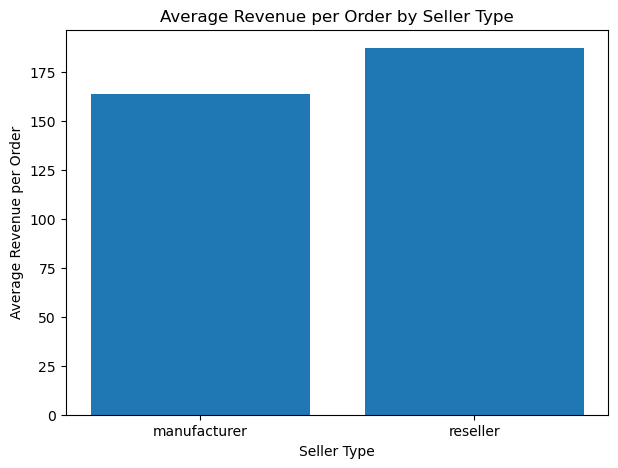

In [148]:
plt.figure(figsize=(7,5))

plt.bar(
    business_type_summary["business_type"],
    business_type_summary["average_revenue_per_order"]
)

plt.title("Average Revenue per Order by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Revenue per Order")
plt.show()

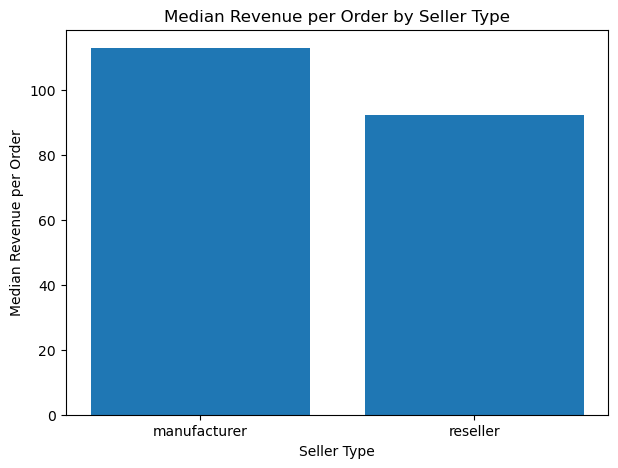

In [150]:
plt.figure(figsize=(7,5))

plt.bar(
    business_type_summary["business_type"],
    business_type_summary["median_revenue_per_order"]
)

plt.title("Median Revenue per Order by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Median Revenue per Order")
plt.show()

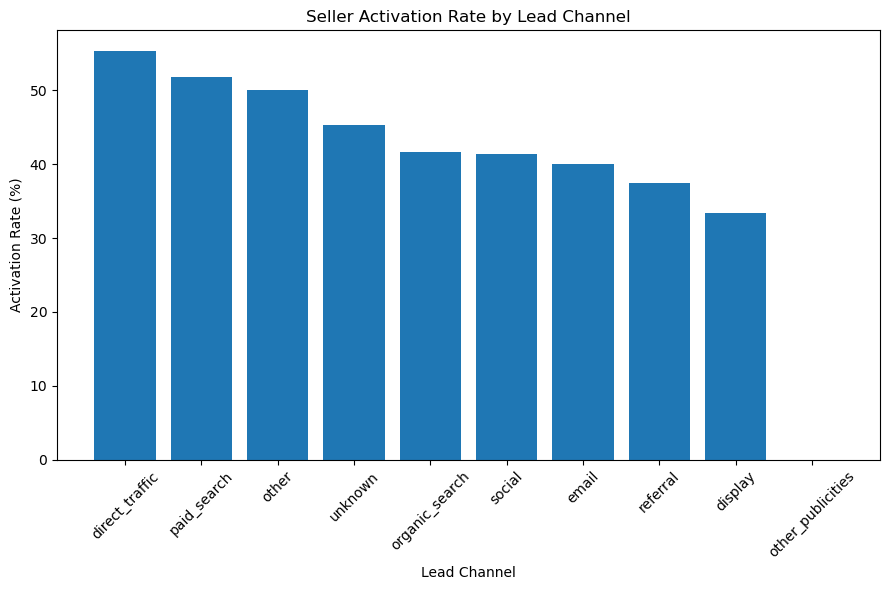

In [155]:
channel_plot = channel_summary.sort_values(
    "active_rate",
    ascending=False
)

plt.figure(figsize=(9,6))

plt.bar(
    channel_plot["origin"],
    channel_plot["active_rate"]
)

plt.title("Seller Activation Rate by Lead Channel")
plt.xlabel("Lead Channel")
plt.ylabel("Activation Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

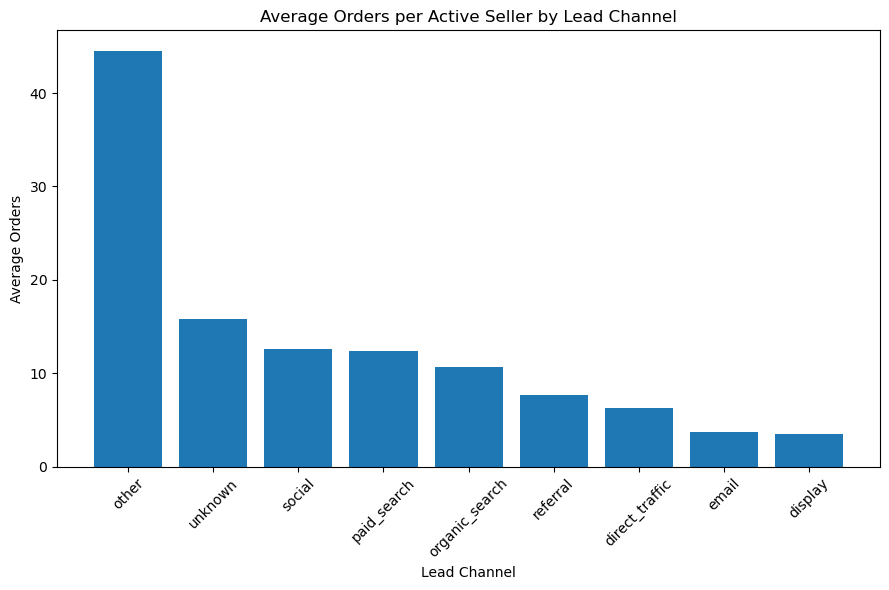

In [157]:
channel_orders_plot = channel_summary.sort_values(
    "average_orders",
    ascending=False
)

plt.figure(figsize=(9,6))

plt.bar(
    channel_orders_plot["origin"],
    channel_orders_plot["average_orders"]
)

plt.title("Average Orders per Active Seller by Lead Channel")
plt.xlabel("Lead Channel")
plt.ylabel("Average Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [159]:
#30/60 day seller activation
activation_timeline = pd.DataFrame({
    "Period": ["Within 30 Days", "Within 60 Days"],
    "Sold": [133, 250],
    "Not Sold": [709, 592]
})

activation_timeline

,Period,Sold,Not Sold
0,Within 30 Days,133,709
1,Within 60 Days,250,592


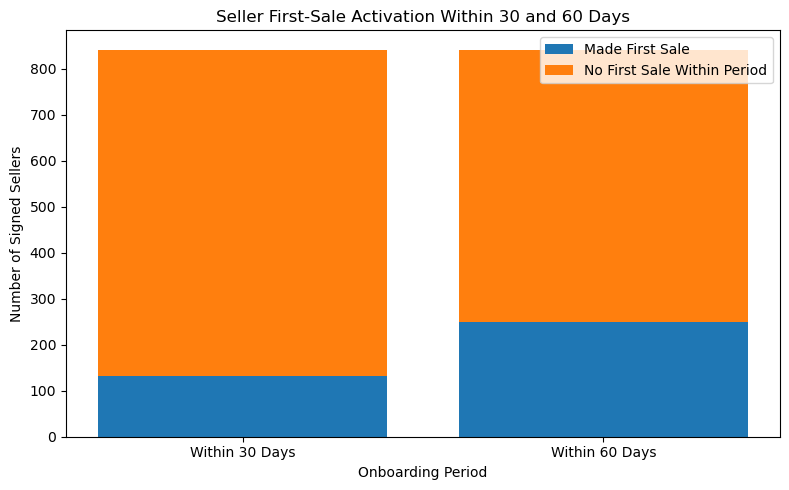

In [161]:
plt.figure(figsize=(8,5))

plt.bar(
    activation_timeline["Period"],
    activation_timeline["Sold"],
    label="Made First Sale"
)

plt.bar(
    activation_timeline["Period"],
    activation_timeline["Not Sold"],
    bottom=activation_timeline["Sold"],
    label="No First Sale Within Period"
)

plt.title("Seller First-Sale Activation Within 30 and 60 Days")
plt.xlabel("Onboarding Period")
plt.ylabel("Number of Signed Sellers")

plt.legend()
plt.tight_layout()
plt.show()

In [163]:
activation_percent = pd.DataFrame({
    "Period": ["Within 30 Days", "Within 60 Days"],
    "Sold_Percentage": [15.80, 29.69],
    "Not_Sold_Percentage": [84.20, 70.31]
})

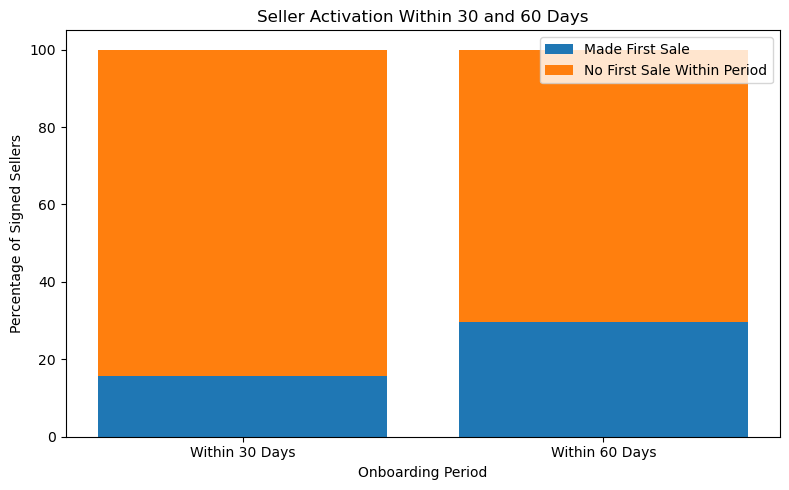

In [165]:
plt.figure(figsize=(8,5))

plt.bar(
    activation_percent["Period"],
    activation_percent["Sold_Percentage"],
    label="Made First Sale"
)

plt.bar(
    activation_percent["Period"],
    activation_percent["Not_Sold_Percentage"],
    bottom=activation_percent["Sold_Percentage"],
    label="No First Sale Within Period"
)

plt.title("Seller Activation Within 30 and 60 Days")
plt.xlabel("Onboarding Period")
plt.ylabel("Percentage of Signed Sellers")

plt.legend()
plt.tight_layout()
plt.show()

In [167]:
#delivery time by seller state
delivery_by_state_fair = delivery_by_state[
    delivery_by_state["orders"] >= 30
].copy()

In [169]:
delivery_state_plot = delivery_by_state_fair.sort_values(
    "average_delivery_days",
    ascending=False
)

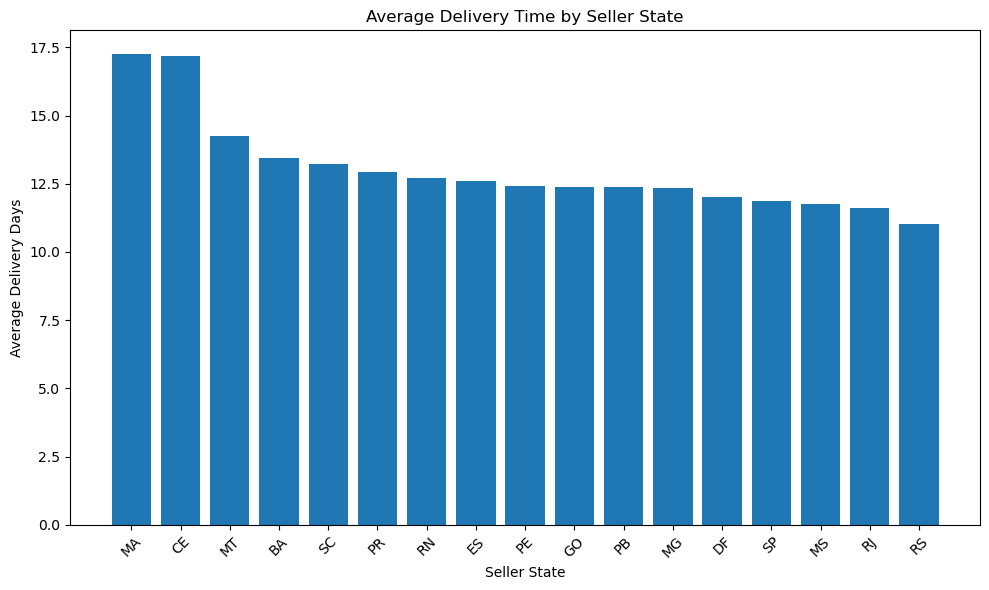

In [171]:
plt.figure(figsize=(10,6))

plt.bar(
    delivery_state_plot["seller_state"],
    delivery_state_plot["average_delivery_days"]
)

plt.title("Average Delivery Time by Seller State")
plt.xlabel("Seller State")
plt.ylabel("Average Delivery Days")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

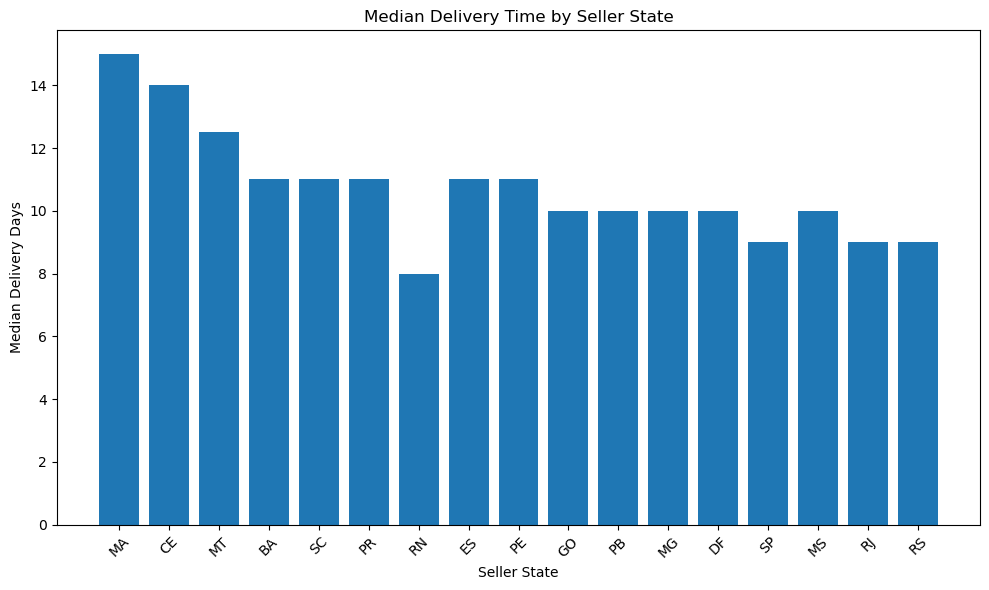

In [173]:
plt.figure(figsize=(10,6))

plt.bar(
    delivery_state_plot["seller_state"],
    delivery_state_plot["median_delivery_days"]
)

plt.title("Median Delivery Time by Seller State")
plt.xlabel("Seller State")
plt.ylabel("Median Delivery Days")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [175]:
#states with customers but no sellers
no_seller_states_plot = customer_activity_no_sellers.sort_values(
    "unique_customers",
    ascending=False
)

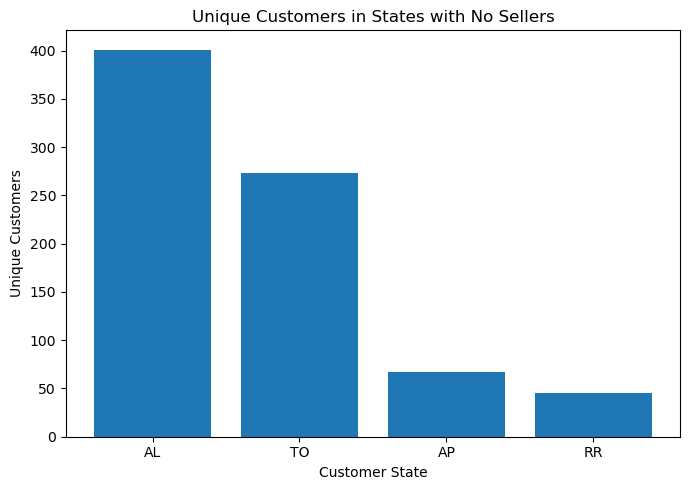

In [177]:
plt.figure(figsize=(7,5))

plt.bar(
    no_seller_states_plot["customer_state"],
    no_seller_states_plot["unique_customers"]
)

plt.title("Unique Customers in States with No Sellers")
plt.xlabel("Customer State")
plt.ylabel("Unique Customers")

plt.tight_layout()
plt.show()

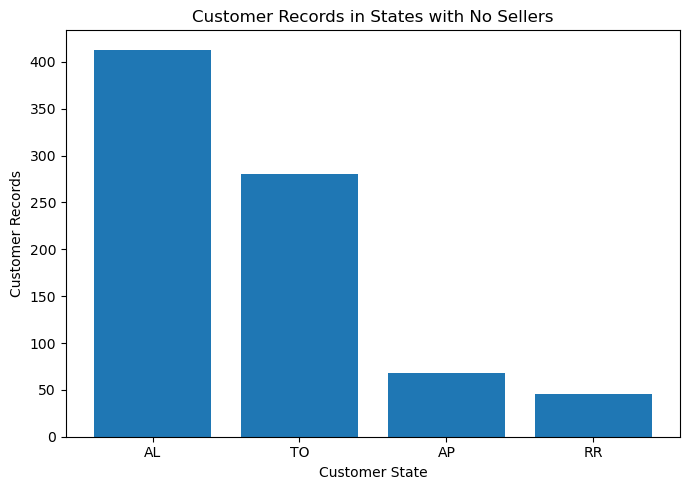

In [179]:
plt.figure(figsize=(7,5))

plt.bar(
    no_seller_states_plot["customer_state"],
    no_seller_states_plot["customer_records"]
)

plt.title("Customer Records in States with No Sellers")
plt.xlabel("Customer State")
plt.ylabel("Customer Records")

plt.tight_layout()
plt.show()

In [181]:
#employee performance
sr_plot = sr_overall_fair.sort_values(
    "revenue_per_hired_seller",
    ascending=False
).head(10)

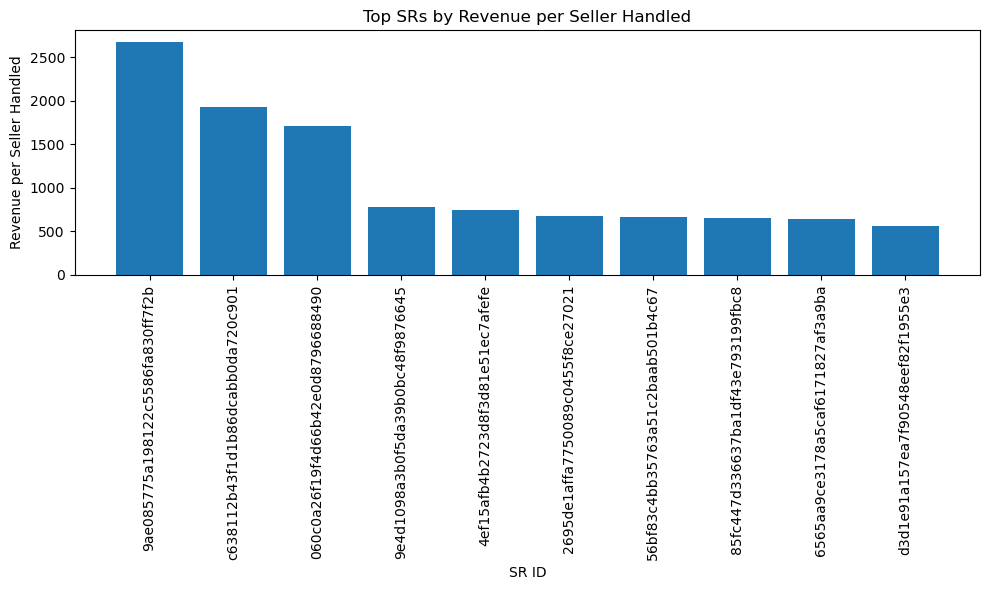

In [183]:
plt.figure(figsize=(10,6))

plt.bar(
    sr_plot["sr_id"],
    sr_plot["revenue_per_hired_seller"]
)

plt.title("Top SRs by Revenue per Seller Handled")
plt.xlabel("SR ID")
plt.ylabel("Revenue per Seller Handled")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [185]:
sr_activation_plot = sr_overall_fair.sort_values(
    "active_rate",
    ascending=False
).head(10)

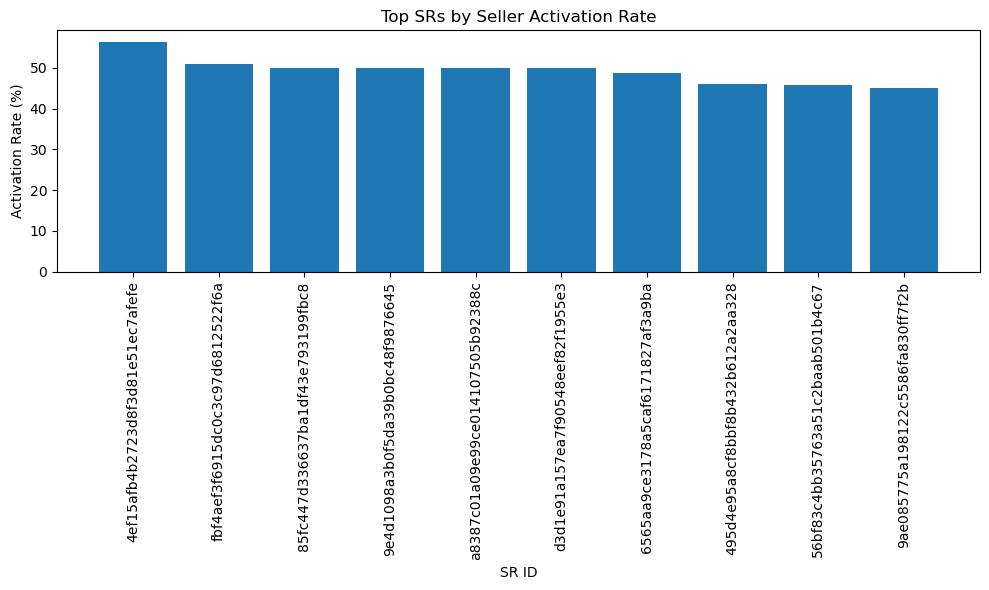

In [187]:
plt.figure(figsize=(10,6))

plt.bar(
    sr_activation_plot["sr_id"],
    sr_activation_plot["active_rate"]
)

plt.title("Top SRs by Seller Activation Rate")
plt.xlabel("SR ID")
plt.ylabel("Activation Rate (%)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [189]:
#SDR performance
sdr_plot = sdr_overall_fair.sort_values(
    "revenue_per_seller",
    ascending=False
).head(10)

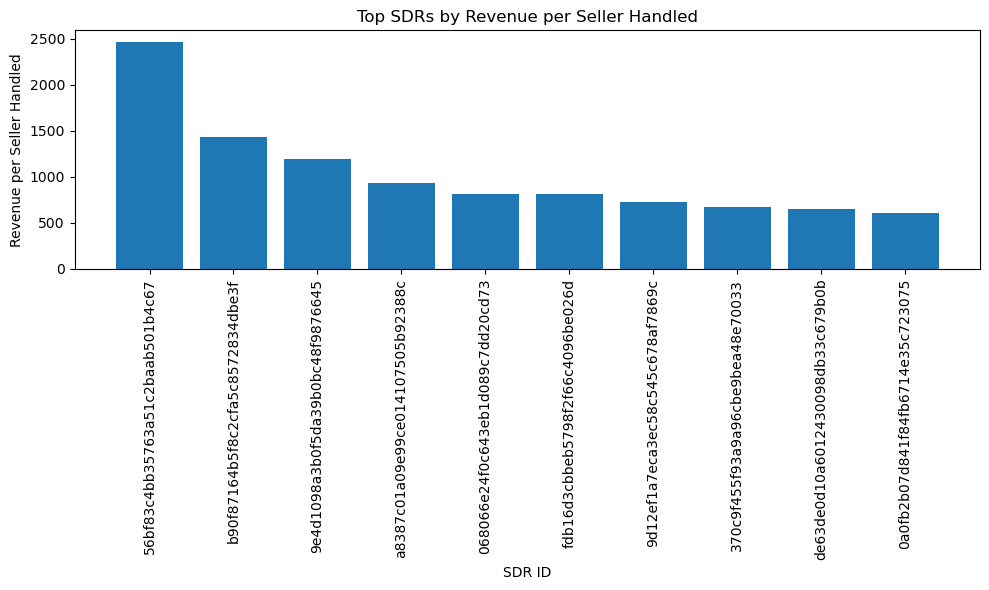

In [191]:
plt.figure(figsize=(10,6))

plt.bar(
    sdr_plot["sdr_id"],
    sdr_plot["revenue_per_seller"]
)

plt.title("Top SDRs by Revenue per Seller Handled")
plt.xlabel("SDR ID")
plt.ylabel("Revenue per Seller Handled")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [193]:
sdr_activation_plot = sdr_overall_fair.sort_values(
    "active_rate",
    ascending=False
).head(10)

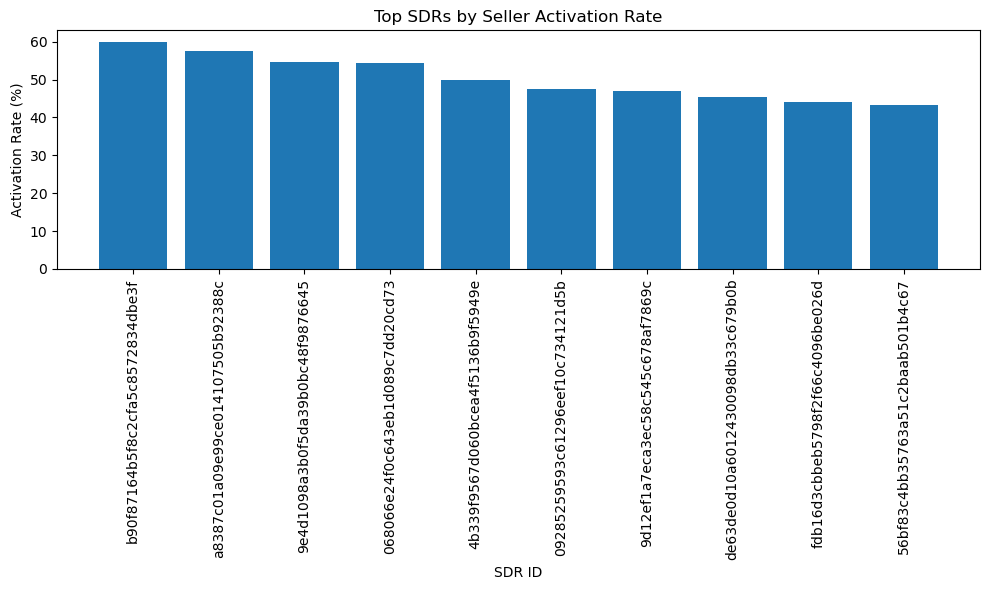

In [195]:
plt.figure(figsize=(10,6))

plt.bar(
    sdr_activation_plot["sdr_id"],
    sdr_activation_plot["active_rate"]
)

plt.title("Top SDRs by Seller Activation Rate")
plt.xlabel("SDR ID")
plt.ylabel("Activation Rate (%)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()